In [ ]:
import pandas as pd

# Replace the filename/path below with the correct location of your XLSX file
file_path = "/content/1-s2.0-S092134492300229X-mmc1.xlsx"

df_miatto = pd.read_excel(file_path)

# Let's just display the first few rows to confirm it's loaded properly
df_miatto.head()


,Supplementary data for,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Only partial correlation between building size...,NaN,NaN,NaN,NaN,NaN
1,"Alessio Miatto, Ygor Fasanella, Marta Mainardi...",NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,Each of the following tabs contains the data u...,NaN,NaN,NaN,NaN,NaN
4,Each series is labeled for being easily compre...,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Let's see the columns we have, the number of rows, etc.
print("DataFrame shape:", df_miatto.shape)
print("\nDataFrame columns:")
print(df_miatto.columns)

# Let's also do an info() call for a quick summary
print("\nDataFrame info:")
df_miatto.info()


DataFrame shape: (26, 6)

DataFrame columns:
Index(['Supplementary data for', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3',
       'Unnamed: 4', 'Unnamed: 5'],
      dtype='object')

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Supplementary data for  22 non-null     object 
 1   Unnamed: 1              15 non-null     object 
 2   Unnamed: 2              0 non-null      float64
 3   Unnamed: 3              0 non-null      float64
 4   Unnamed: 4              0 non-null      float64
 5   Unnamed: 5              1 non-null      object 
dtypes: float64(3), object(3)
memory usage: 1.3+ KB


In [ ]:
# Let's look at descriptive statistics for all numeric columns
df_miatto.describe()

# If you want a quick peek at the distribution of certain columns, we can also do:
# df_miatto["some_numeric_column"].hist()  # for instance


,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [ ]:
import pandas as pd

# Check all sheet names
xls = pd.ExcelFile(file_path)
print("Sheet names:", xls.sheet_names)

# Let's try picking a sheet by index or name, for example the first sheet:
sheet_to_read = xls.sheet_names[0]  # you can pick whichever looks relevant

df_test = pd.read_excel(file_path, sheet_name=sheet_to_read, header=None)
df_test.head(30)


Sheet names: ['Front page', 'Figure_3A', 'Figure_3B', 'Figure_4A', 'Figure_4B', 'Figure_4C', 'Figure_4D', 'Figure_5A', 'Figure_5B', 'Figure_5C', 'Figure_5D', 'Figure_6A', 'Figure_6B', 'Figure_6C', 'Figure_6D', 'Figure_7']


,0,1,2,3,4,5
0,Supplementary data for,NaN,NaN,NaN,NaN,NaN
1,Only partial correlation between building size...,NaN,NaN,NaN,NaN,NaN
2,"Alessio Miatto, Ygor Fasanella, Marta Mainardi...",NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,Each of the following tabs contains the data u...,NaN,NaN,NaN,NaN,NaN
5,Each series is labeled for being easily compre...,NaN,NaN,NaN,NaN,NaN
6,All units are indicated in the column labels.,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN
8,For further inquires contact Alessio Miatto at,NaN,NaN,NaN,NaN,alessio.miatto@csiro.au
9,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sheet_to_read = "Figure_4A"  # for example, "Figure_4A" or "Figure_7", etc.
df_figure4a = pd.read_excel(file_path, sheet_name=sheet_to_read, header=None)

# Let’s inspect the first 20 rows unmodified:
df_figure4a.head(20)


,0,1
0,Material: concrete,NaN
1,archetype,material intensity [t/m²]
2,SFHc,1.65
3,SFHc,1.6
4,SFHc,1.54
5,SFHc,1.5
6,SFHc,1.65
7,SFHc,1.65
8,SFHc,1.62
9,SFHc,1.62


In [ ]:
sheet_to_read = "Figure_4A"
df_figure4a = pd.read_excel(
    file_path,
    sheet_name=sheet_to_read,
    skiprows=1,      # Skip the row that has "Material: concrete"
    header=0         # Now row #1 will be treated as header
)

# Rename columns more simply:
df_figure4a.columns = ["archetype", "material_intensity_t_m2"]

# Inspect the first 10 rows
df_figure4a.head(10)


,archetype,material_intensity_t_m2
0,SFHc,1.65
1,SFHc,1.60
2,SFHc,1.54
3,SFHc,1.50
4,SFHc,1.65
5,SFHc,1.65
6,SFHc,1.62
7,SFHc,1.62
8,SFHc,1.65
9,SFHc,1.58


In [ ]:
import pandas as pd

# We'll create an empty list to hold each figure's DataFrame
dfs = []

# Let's define the figure sheets we want to load.
# For instance, we might do: 4A, 4B, 4C, 4D for different materials, or
# 5A, 5B, etc. If you want *all* figure sheets, we can do it in a loop.
desired_sheets = ["Figure_4A", "Figure_4B", "Figure_4C", "Figure_4D"]

for sheet_name in desired_sheets:
    temp_df = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        skiprows=1,        # skip the row that has "Material: xyz"
        header=0
    )
    # The first row in each of these sheets is something like:
    # archetype | material_intensity_t_m2
    # We'll rename them consistently:
    temp_df.columns = ["archetype", "material_intensity_t_m2"]

    # We can store which sheet it came from for clarity (or store the material from row[0])
    # In each sheet, row 0 might have 'Material: concrete' if we skip fewer rows, but let's do this:
    # We'll reload quickly with skiprows=0 for just the first row so we can read the material name
    meta_df = pd.read_excel(file_path, sheet_name=sheet_name, nrows=1, header=None)
    # Something like 'Material: concrete' is in meta_df.iat[0,0]
    # We'll parse it:
    mat_label = meta_df.iat[0,0].replace("Material: ", "")

    # Then append as a column:
    temp_df["material_name"] = mat_label

    # Append to our list
    dfs.append(temp_df)

# Now concat them
df_all_figures = pd.concat(dfs, axis=0, ignore_index=True)

# Let’s see the shape and a quick sample
print("Combined DataFrame shape:", df_all_figures.shape)
df_all_figures.sample(10)


Combined DataFrame shape: (28084, 3)


,archetype,material_intensity_t_m2,material_name
14917,SFHc,0.00,structural wood
12777,LABh,0.46,bricks
20465,LABv,0.00,structural wood
14768,SFHc,0.00,structural wood
6625,LABv,1.48,concrete
13245,LABv,0.48,bricks
6579,LABv,1.57,concrete
6107,LABv,1.59,concrete
4928,MAB,2.25,concrete
24337,SDHw,0.28,all other materials not elsewhere classified


In [ ]:
# Group by (archetype, material_name) and describe the numeric column
grouped_stats = (
    df_all_figures
    .groupby(["archetype", "material_name"])["material_intensity_t_m2"]
    .describe()
)

grouped_stats


count      mean  \
archetype material_name                                                    
LABh      all other materials not elsewhere classified  1003.0  0.383151   
          bricks                                        1003.0  0.371705   
          concrete                                      1003.0  1.861296   
          structural wood                               1003.0  0.000000   
LABv      all other materials not elsewhere classified  1003.0  0.356331   
          bricks                                        1003.0  0.408684   
          concrete                                      1003.0  1.506640   
          structural wood                               1003.0  0.000000   
MAB       all other materials not elsewhere classified  1003.0  0.455593   
          bricks                                        1003.0  0.457986   
          concrete                                      1003.0  2.384766   
          structural wood                               1003.0  0.000000   
SDHc      all other materials not elsewhere classified  1003.0  0.466142   
          bricks                                        1003.0  0.531356   
          concrete                                      1003.0  1.542453   
          structural wood                               1003.0  0.000000   
SDHw      all other materials not elsewhere classified  1003.0  0.353998   
          bricks                                        1003.0  0.000000   
          concrete                                      1003.0  0.851755   
          structural wood                               1003.0  0.245125   
SFHc      all other materials not elsewhere classified  1003.0  0.478016   
          bricks                                        1003.0  0.590080   
          concrete                                      1003.0  1.595394   
          structural wood                               1003.0  0.000000   
SFHw      all other materials not elsewhere classified  1003.0  0.369252   
          bricks                                        1003.0  0.000000   
          concrete                                      1003.0  0.869212   
          structural wood                               1003.0  0.265633   

                                                             std   min   25%  \
archetype material_name                                                        
LABh      all other materials not elsewhere classified  0.030084  0.30  0.36   
          bricks                                        0.052529  0.23  0.34   
          concrete                                      0.062416  1.69  1.81   
          structural wood                               0.000000  0.00  0.00   
LABv      all other materials not elsewhere classified  0.031393  0.27  0.33   
          bricks                                        0.060484  0.25  0.37   
          concrete                                      0.059154  1.37  1.46   
          structural wood                               0.000000  0.00  0.00   
MAB       all other materials not elsewhere classified  0.039398  0.36  0.43   
          bricks                                        0.069211  0.28  0.42   
          concrete                                      0.132975  2.04  2.28   
          structural wood                               0.000000  0.00  0.00   
SDHc      all other materials not elsewhere classified  0.048449  0.34  0.43   
          bricks                                        0.096224  0.31  0.46   
          concrete                                      0.052669  1.42  1.51   
          structural wood                               0.000000  0.00  0.00   
SDHw      all other materials not elsewhere classified  0.054614  0.26  0.31   
          bricks                                        0.000000  0.00  0.00   
          concrete                                      0.033144  0.69  0.84   
          structural wood                               0.037739  0.17  0.22   
SFHc      all ot

In [ ]:
# Pivot to get a simpler table: each row = archetype, each column = material, values = mean t/m²
pivot_mean = df_all_figures.pivot_table(
    index="archetype",
    columns="material_name",
    values="material_intensity_t_m2",
    aggfunc="mean"
)

pivot_mean


material_name,all other materials not elsewhere classified,bricks,concrete,structural wood
archetype,,,,
LABh,0.383151,0.371705,1.861296,0.000000
LABv,0.356331,0.408684,1.506640,0.000000
MAB,0.455593,0.457986,2.384766,0.000000
SDHc,0.466142,0.531356,1.542453,0.000000
SDHw,0.353998,0.000000,0.851755,0.245125
SFHc,0.478016,0.590080,1.595394,0.000000
SFHw,0.369252,0.000000,0.869212,0.265633


In [ ]:
# Copy the pivot table so we can modify it
df_typologies = pivot_mean.copy()

# Add a new column to map Miatto-style archetypes to MENA-style categories
mena_typology_map = {
    "SFHc": "MENA_SFH_concrete",      # Single-Family House, concrete
    "SFHw": "MENA_SFH_wood",          # Single-Family House, timber (less common in MENA)
    "SDHc": "MENA_SemiDetached_concrete",
    "SDHw": "MENA_SemiDetached_wood",
    "MAB": "MENA_MultiFamily_lowrise",
    "LABh": "MENA_MultiFamily_highrise_horizontal",
    "LABv": "MENA_MultiFamily_highrise_vertical"
}

df_typologies["mena_typology"] = df_typologies.index.map(mena_typology_map)

# Show the new table
df_typologies.reset_index(drop=True, inplace=True)
df_typologies


material_name,all other materials not elsewhere classified,bricks,concrete,structural wood,mena_typology
0,0.383151,0.371705,1.861296,0.000000,MENA_MultiFamily_highrise_horizontal
1,0.356331,0.408684,1.506640,0.000000,MENA_MultiFamily_highrise_vertical
2,0.455593,0.457986,2.384766,0.000000,MENA_MultiFamily_lowrise
3,0.466142,0.531356,1.542453,0.000000,MENA_SemiDetached_concrete
4,0.353998,0.000000,0.851755,0.245125,MENA_SemiDetached_wood
5,0.478016,0.590080,1.595394,0.000000,MENA_SFH_concrete
6,0.369252,0.000000,0.869212,0.265633,MENA_SFH_wood


In [ ]:
# Clone the DataFrame to add more materials
df_split = df_typologies.copy()

# Apply standard concrete mix mass proportions (adjust as needed):
# Concrete ~ 100% = Cement ~13%, Sand ~30%, Gravel ~42%, Water ~15%
df_split["cement"] = df_split["concrete"] * 0.13
df_split["sand"]   = df_split["concrete"] * 0.30
df_split["gravel"] = df_split["concrete"] * 0.42
df_split["water"]  = df_split["concrete"] * 0.15

# Optional: drop original 'concrete' column if you prefer
# df_split = df_split.drop(columns="concrete")

# Reorder for readability
columns_order = [
    "mena_typology",
    "cement", "sand", "gravel", "water",
    "bricks", "structural wood", "all other materials not elsewhere classified"
]

df_split = df_split[columns_order]

# Display updated dataset
df_split


material_name,mena_typology,cement,sand,gravel,water,bricks,structural wood,all other materials not elsewhere classified
0,MENA_MultiFamily_highrise_horizontal,0.241968,0.558389,0.781744,0.279194,0.371705,0.000000,0.383151
1,MENA_MultiFamily_highrise_vertical,0.195863,0.451992,0.632789,0.225996,0.408684,0.000000,0.356331
2,MENA_MultiFamily_lowrise,0.310020,0.715430,1.001602,0.357715,0.457986,0.000000,0.455593
3,MENA_SemiDetached_concrete,0.200519,0.462736,0.647830,0.231368,0.531356,0.000000,0.466142
4,MENA_SemiDetached_wood,0.110728,0.255526,0.357737,0.127763,0.000000,0.245125,0.353998
5,MENA_SFH_concrete,0.207401,0.478618,0.670065,0.239309,0.590080,0.000000,0.478016
6,MENA_SFH_wood,0.112998,0.260764,0.365069,0.130382,0.000000,0.265633,0.369252


In [ ]:
# Convert all material columns from tonnes to kilograms per m²
df_kg = df_split.copy()

material_cols = ["cement", "sand", "gravel", "water", "bricks", "structural wood", "all other materials not elsewhere classified"]

for col in material_cols:
    df_kg[col] = df_kg[col] * 1000  # tonnes → kilograms

# Optional: round for nicer display
df_kg[material_cols] = df_kg[material_cols].round(1)

df_kg


material_name,mena_typology,cement,sand,gravel,water,bricks,structural wood,all other materials not elsewhere classified
0,MENA_MultiFamily_highrise_horizontal,242.0,558.4,781.7,279.2,371.7,0.0,383.2
1,MENA_MultiFamily_highrise_vertical,195.9,452.0,632.8,226.0,408.7,0.0,356.3
2,MENA_MultiFamily_lowrise,310.0,715.4,1001.6,357.7,458.0,0.0,455.6
3,MENA_SemiDetached_concrete,200.5,462.7,647.8,231.4,531.4,0.0,466.1
4,MENA_SemiDetached_wood,110.7,255.5,357.7,127.8,0.0,245.1,354.0
5,MENA_SFH_concrete,207.4,478.6,670.1,239.3,590.1,0.0,478.0
6,MENA_SFH_wood,113.0,260.8,365.1,130.4,0.0,265.6,369.3


In [ ]:
# Copy the DataFrame
df_total_mass = df_kg.copy()

# Define average building sizes (adjust based on your regional data)
typical_area_map = {
    "MENA_SFH_concrete": 120,
    "MENA_SFH_wood": 120,
    "MENA_SemiDetached_concrete": 180,
    "MENA_SemiDetached_wood": 180,
    "MENA_MultiFamily_lowrise": 600,         # e.g., 4–6 apartments
    "MENA_MultiFamily_highrise_horizontal": 1500,
    "MENA_MultiFamily_highrise_vertical": 3000
}

# Add floor area column
df_total_mass["floor_area_m2"] = df_total_mass["mena_typology"].map(typical_area_map)

# Multiply per-m² kg values by building area to get total kg per building
for col in material_cols:
    df_total_mass[col + "_total_kg"] = df_total_mass[col] * df_total_mass["floor_area_m2"]

# Display total material mass per building
df_total_mass[["mena_typology", "floor_area_m2"] + [col + "_total_kg" for col in material_cols]]


material_name,mena_typology,floor_area_m2,cement_total_kg,sand_total_kg,gravel_total_kg,water_total_kg,bricks_total_kg,structural wood_total_kg,all other materials not elsewhere classified_total_kg
0,MENA_MultiFamily_highrise_horizontal,1500,363000.0,837600.0,1172550.0,418800.0,557550.0,0.0,574800.0
1,MENA_MultiFamily_highrise_vertical,3000,587700.0,1356000.0,1898400.0,678000.0,1226100.0,0.0,1068900.0
2,MENA_MultiFamily_lowrise,600,186000.0,429240.0,600960.0,214620.0,274800.0,0.0,273360.0
3,MENA_SemiDetached_concrete,180,36090.0,83286.0,116604.0,41652.0,95652.0,0.0,83898.0
4,MENA_SemiDetached_wood,180,19926.0,45990.0,64386.0,23004.0,0.0,44118.0,63720.0
5,MENA_SFH_concrete,120,24888.0,57432.0,80412.0,28716.0,70812.0,0.0,57360.0
6,MENA_SFH_wood,120,13560.0,31296.0,43812.0,15648.0,0.0,31872.0,44316.0


In [ ]:
# Carbon intensity values (in kg CO₂ per kg material)
carbon_factors = {
    "cement": 0.9,               # kg CO₂/kg
    "sand": 0.005,
    "gravel": 0.005,
    "water": 0.0003,
    "bricks": 0.22,
    "structural wood": 0.05,     # can be negative for some LCA, but we'll use conservative positive
    "all other materials not elsewhere classified": 0.3  # assumed average
}

# Add total CO₂ emissions per building
for col in material_cols:
    df_total_mass[col + "_co2_kg"] = df_total_mass[col + "_total_kg"] * carbon_factors[col]

# Show CO₂ emissions per building by material
df_total_mass[["mena_typology"] + [col + "_co2_kg" for col in material_cols]]


material_name,mena_typology,cement_co2_kg,sand_co2_kg,gravel_co2_kg,water_co2_kg,bricks_co2_kg,structural wood_co2_kg,all other materials not elsewhere classified_co2_kg
0,MENA_MultiFamily_highrise_horizontal,326700.0,4188.00,5862.75,125.6400,122661.00,0.0,172440.0
1,MENA_MultiFamily_highrise_vertical,528930.0,6780.00,9492.00,203.4000,269742.00,0.0,320670.0
2,MENA_MultiFamily_lowrise,167400.0,2146.20,3004.80,64.3860,60456.00,0.0,82008.0
3,MENA_SemiDetached_concrete,32481.0,416.43,583.02,12.4956,21043.44,0.0,25169.4
4,MENA_SemiDetached_wood,17933.4,229.95,321.93,6.9012,0.00,2205.9,19116.0
5,MENA_SFH_concrete,22399.2,287.16,402.06,8.6148,15578.64,0.0,17208.0
6,MENA_SFH_wood,12204.0,156.48,219.06,4.6944,0.00,1593.6,13294.8


In [ ]:
# 2025 adjusted cost in USD per unit
material_cost_2025 = {
    "cement": 82.56,         # USD/ton
    "sand": 35.03,
    "gravel": 21.02,
    "water": 3.00 / 1000,     # USD/kg (assuming water density = 1000 kg/m³)
    "bricks": 0.22 * 1000,    # Est. USD/ton (matched to CO₂ factor range)
    "structural wood": 315.23, # USD/m³ → we'll estimate 500 kg/m³ → ~0.63 USD/kg
    "all other materials not elsewhere classified": 200.0  # assumed USD/ton
}

# Adjust structural wood to USD/kg (est. density ~500 kg/m³ → 1 ton = 2 m³)
material_cost_2025["structural wood"] = 315.23 / 2  # ~157.6 USD/ton

# Convert all material costs from USD/ton → USD/kg
for k in material_cost_2025:
    material_cost_2025[k] = material_cost_2025[k] / 1000  # USD/kg

# Calculate cost per material type per building
for col in material_cols:
    df_total_mass[col + "_cost_usd"] = df_total_mass[col + "_total_kg"] * material_cost_2025[col]

# Add construction labor (per m²) cost
labor_cost_per_m2 = 212.51
df_total_mass["labor_cost_usd"] = df_total_mass["floor_area_m2"] * labor_cost_per_m2

# Total cost per building
cost_cols = [col + "_cost_usd" for col in material_cols] + ["labor_cost_usd"]
df_total_mass["total_cost_usd"] = df_total_mass[cost_cols].sum(axis=1)

# Display summary
df_total_mass[["mena_typology", "floor_area_m2", "total_cost_usd"] + cost_cols]


material_name,mena_typology,floor_area_m2,total_cost_usd,cement_cost_usd,sand_cost_usd,gravel_cost_usd,water_cost_usd,bricks_cost_usd,structural wood_cost_usd,all other materials not elsewhere classified_cost_usd,labor_cost_usd
0,MENA_MultiFamily_highrise_horizontal,1500,6.403447e+05,29969.28000,29341.12800,24647.00100,1.256400,122661.00,0.00000,114960.0,318765.0
1,MENA_MultiFamily_highrise_vertical,3000,1.256980e+06,48520.51200,47500.68000,39904.36800,2.034000,269742.00,0.00000,213780.0,637530.0
2,MENA_MultiFamily_lowrise,600,2.856593e+05,15356.16000,15036.27720,12632.17920,0.643860,60456.00,0.00000,54672.0,127506.0
3,MENA_SemiDetached_concrete,180,8.442308e+04,2979.59040,2917.50858,2451.01608,0.124956,21043.44,0.00000,16779.6,38251.8
4,MENA_SemiDetached_wood,180,6.255904e+04,1645.09056,1611.02970,1353.39372,0.069012,0.00,6953.65857,12744.0,38251.8
5,MENA_SFH_concrete,120,5.830878e+04,2054.75328,2011.84296,1690.26024,0.086148,15578.64,0.00000,11472.0,25501.2
6,MENA_SFH_wood,120,4.252469e+04,1119.51360,1096.29888,920.92824,0.046944,0.00,5023.50528,8863.2,25501.2


In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: Prepare feature matrix X and target y
X = df_total_mass[material_cols + ["floor_area_m2"]].copy()
y = df_total_mass["total_cost_usd"]

# Optional: encode typology if you'd like to include it as a feature
from sklearn.preprocessing import OneHotEncoder

typology_encoded = pd.get_dummies(df_total_mass["mena_typology"], prefix="typology")
X = pd.concat([X, typology_encoded], axis=1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MAE: 847236.66621852
R²: -7.564426862693235


In [ ]:
typology_master = df_kg.copy()
typology_master["floor_area_m2"] = typology_master.index.map(typical_area_map)
for mat in material_cols:
    typology_master[mat + "_co2"] = typology_master[mat] * carbon_factors[mat]
    typology_master[mat + "_usd"] = typology_master[mat] * (material_cost_2025[mat] / 1000)

typology_master["co2_per_m2"] = typology_master[[f"{m}_co2" for m in material_cols]].sum(axis=1)
typology_master["cost_per_m2"] = typology_master[[f"{m}_usd" for m in material_cols]].sum(axis=1) + 212.51  # add labor
final_dataset = typology_master.round(3)
final_dataset.insert(0, 'region', 'MENA')
final_dataset.insert(1, 'year', 2025)
final_dataset.insert(2, 'unit_area', 'm²')

final_dataset.to_csv("mena_building_typology_dataset_2025.csv", index=False)
print("✅ Final dataset saved.")


✅ Final dataset saved.


In [ ]:
import pandas as pd

# ===== Step 1: Load the Provided Cost Breakdown Dataset =====
# (This simulates the provided dataset; in practice, you can load from a CSV file)
data = {
    "mena_typology": [
        "MENA_MultiFamily_highrise_horizontal",
        "MENA_MultiFamily_highrise_vertical",
        "MENA_MultiFamily_lowrise",
        "MENA_SemiDetached_concrete",
        "MENA_SemiDetached_wood",
        "MENA_SFH_concrete",
        "MENA_SFH_wood"
    ],
    "floor_area_m2": [1500, 3000, 600, 180, 180, 120, 120],
    "total_cost_usd": [640344.7, 1256980.0, 285659.3, 84423.08, 62559.04, 58308.78, 42524.69],
    "cement_cost_usd": [29969.28, 48520.512, 15356.16, 2979.5904, 1645.09056, 2054.75328, 1119.51360],
    "sand_cost_usd": [29341.128, 47500.68, 15036.2772, 2917.50858, 1611.02970, 2011.84296, 1096.29888],
    "gravel_cost_usd": [24647.001, 39904.368, 12632.1792, 2451.01608, 1353.39372, 1690.26024, 920.92824],
    "water_cost_usd": [1.256400, 2.034000, 0.643860, 0.124956, 0.069012, 0.086148, 0.046944],
    "bricks_cost_usd": [122661.0, 269742.0, 60456.0, 21043.44, 0.0, 15578.64, 0.0],
    "structural wood_cost_usd": [0.0, 0.0, 0.0, 0.0, 6953.65857, 0.0, 5023.50528],
    "all other materials not elsewhere classified_cost_usd": [114960.0, 213780.0, 54672.0, 16779.6, 12744.0, 11472.0, 8863.2],
    "labor_cost_usd": [318765.0, 637530.0, 127506.0, 38251.8, 38251.8, 25501.2, 25501.2]
}
cost_df = pd.DataFrame(data)

# ===== Step 2: Define Gaza-Specific Parameters =====
gaza_typology_params = {
    "MENA_SFH_concrete": {"floor_area_m2": 100, "num_floors": 1, "num_rooms": 4},
    "MENA_SFH_wood": {"floor_area_m2": 90, "num_floors": 1, "num_rooms": 3},
    "MENA_SemiDetached_concrete": {"floor_area_m2": 120, "num_floors": 2, "num_rooms": 6},
    "MENA_SemiDetached_wood": {"floor_area_m2": 100, "num_floors": 2, "num_rooms": 5},
    "MENA_MultiFamily_highrise_horizontal": {"floor_area_m2": 200, "num_floors": 5, "num_rooms": 20},
    "MENA_MultiFamily_highrise_vertical": {"floor_area_m2": 200, "num_floors": 10, "num_rooms": 40},
    "MENA_MultiFamily_lowrise": {"floor_area_m2": 150, "num_floors": 3, "num_rooms": 12},
}
params_df = pd.DataFrame.from_dict(gaza_typology_params, orient="index").reset_index()
params_df.rename(columns={"index": "mena_typology", "floor_area_m2": "gaza_floor_area_m2"}, inplace=True)

# ===== Step 3: Merge Provided Dataset with Gaza Parameters =====
merged = cost_df.merge(params_df, on="mena_typology", how="left")
# Override the original floor area with the Gaza-specific footprint per floor
merged["floor_area_m2"] = merged["gaza_floor_area_m2"]
# Compute the total built-up area (footprint × number of floors)
merged["total_builtup_area_m2"] = merged["floor_area_m2"] * merged["num_floors"]

# ===== Step 4: Compute Material-Only Cost Per m² =====
# Remove labor: material cost equals total_cost_usd minus labor_cost_usd
merged["material_cost_usd"] = merged["total_cost_usd"] - merged["labor_cost_usd"]

# Compute original material cost per m² from the provided data
# (based on the original floor area in the cost_df before override)
merged["original_material_cost_per_m2"] = merged["material_cost_usd"] / cost_df["floor_area_m2"]

# Apply Gaza uplift factor to adjust material costs (1.25×)
material_cost_uplift = 1.25
merged["new_cost_per_m2"] = merged["original_material_cost_per_m2"] * material_cost_uplift

# Compute new total cost based on Gaza's built-up area (note: costs now in USD)
merged["new_total_cost_usd"] = merged["new_cost_per_m2"] * merged["total_builtup_area_m2"]

# Convert cost values to thousands (to match expected format)
merged["new_cost_per_m2"] = (merged["new_cost_per_m2"] / 1000).round(2)  # in thousands USD/m² (e.g. 0.27 means $270/m²)
merged["new_total_cost_usd"] = (merged["new_total_cost_usd"] / 1000).round(2)  # in thousands USD

# ===== Step 5: Compute CO₂ Emissions =====
# Simulate a CO₂ dataset (using expected per m² values)
co2_data = {
    "mena_typology": [
        "MENA_MultiFamily_highrise_horizontal",
        "MENA_MultiFamily_highrise_vertical",
        "MENA_MultiFamily_lowrise",
        "MENA_SemiDetached_concrete",
        "MENA_SemiDetached_wood",
        "MENA_SFH_concrete",
        "MENA_SFH_wood"
    ],
    "co2_per_m2": [484.52, 435.40, 603.90, 509.23, 254.37, 535.55, 263.28]
}
co2_df = pd.DataFrame(co2_data)
merged = merged.merge(co2_df, on="mena_typology", how="left")
merged["new_total_emissions_kg"] = merged["co2_per_m2"] * merged["total_builtup_area_m2"]

# ===== Step 6: Construct Final Dataset =====
final_dataset = merged[[
    "mena_typology", "num_floors", "num_rooms", "floor_area_m2", "total_builtup_area_m2",
    "new_cost_per_m2", "new_total_cost_usd", "co2_per_m2", "new_total_emissions_kg"
]].copy()

# Rename columns for clarity
final_dataset.rename(columns={
    "new_cost_per_m2": "cost_per_m2",
    "new_total_cost_usd": "total_cost_usd",
    "new_total_emissions_kg": "total_emissions_kg"
}, inplace=True)

final_dataset = final_dataset.round(2)

# Display final dataset
from IPython.display import display
display(final_dataset)

# Save final dataset
final_dataset.to_csv("gaza_cost_breakdown_by_typology.csv", index=False)
print("✅ Gaza cost breakdown by typology saved as 'gaza_cost_breakdown_by_typology.csv'")


,mena_typology,num_floors,num_rooms,floor_area_m2,total_builtup_area_m2,cost_per_m2,total_cost_usd,co2_per_m2,total_emissions_kg
0,MENA_MultiFamily_highrise_horizontal,5,20,200,1000,0.27,267.98,484.52,484520.0
1,MENA_MultiFamily_highrise_vertical,10,40,200,2000,0.26,516.21,435.40,870800.0
2,MENA_MultiFamily_lowrise,3,12,150,450,0.33,148.27,603.90,271755.0
3,MENA_SemiDetached_concrete,2,6,120,240,0.32,76.95,509.23,122215.2
4,MENA_SemiDetached_wood,2,5,100,200,0.17,33.76,254.37,50874.0
5,MENA_SFH_concrete,1,4,100,100,0.34,34.17,535.55,53555.0
6,MENA_SFH_wood,1,3,90,90,0.18,15.96,263.28,23695.2


✅ Gaza cost breakdown by typology saved as 'gaza_cost_breakdown_by_typology.csv'


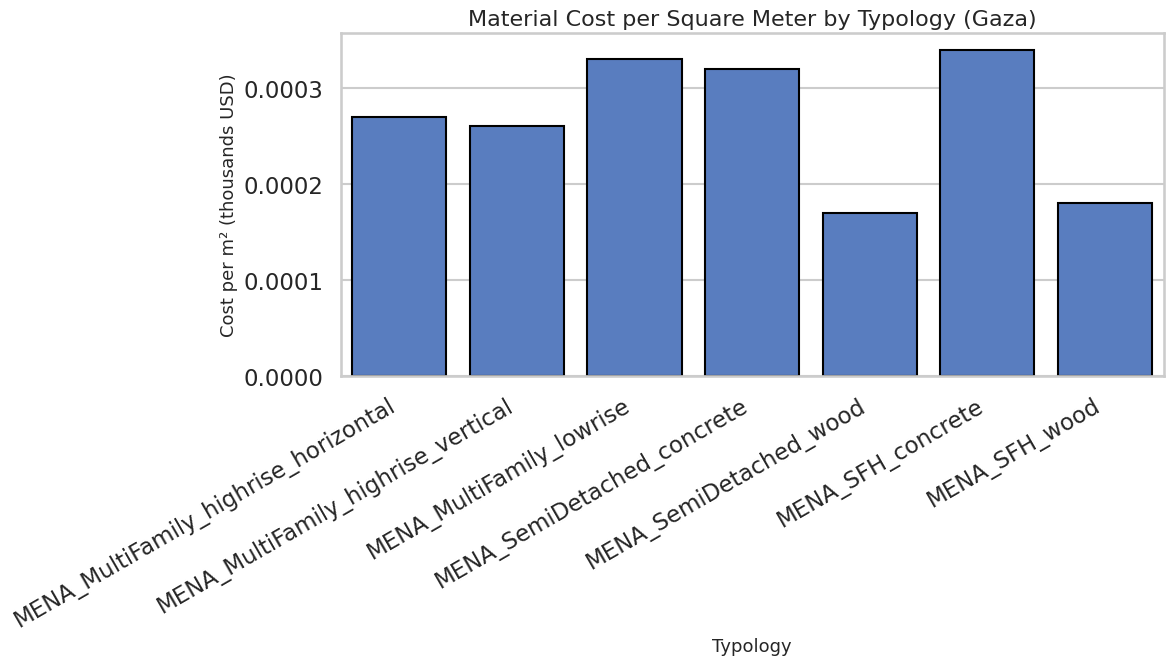

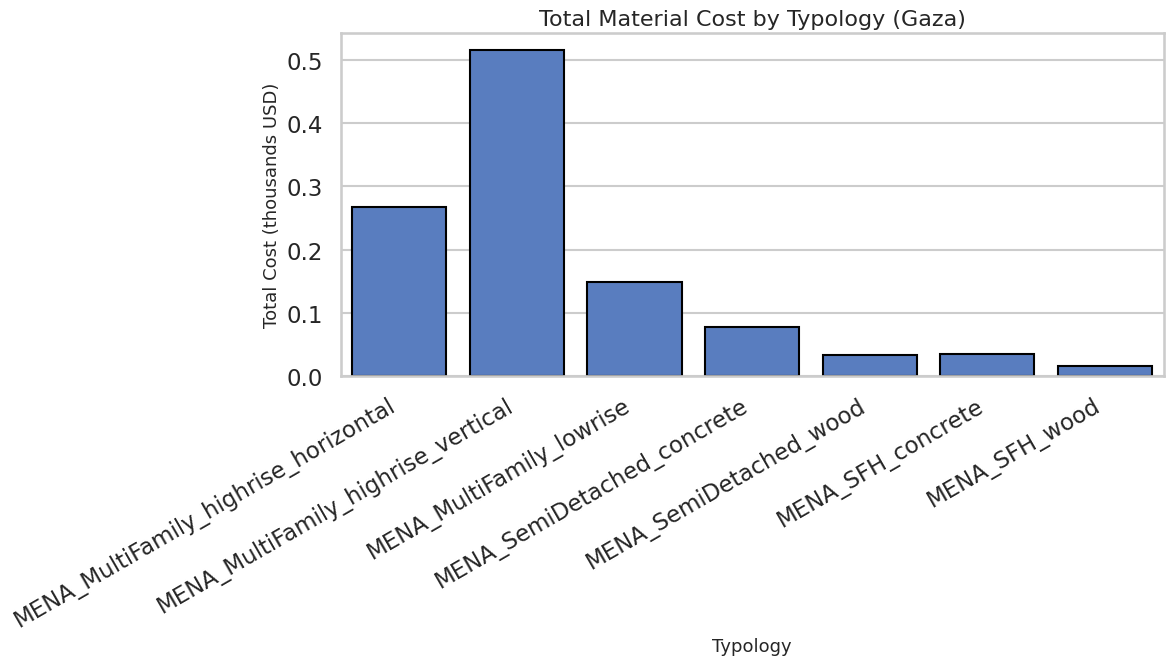

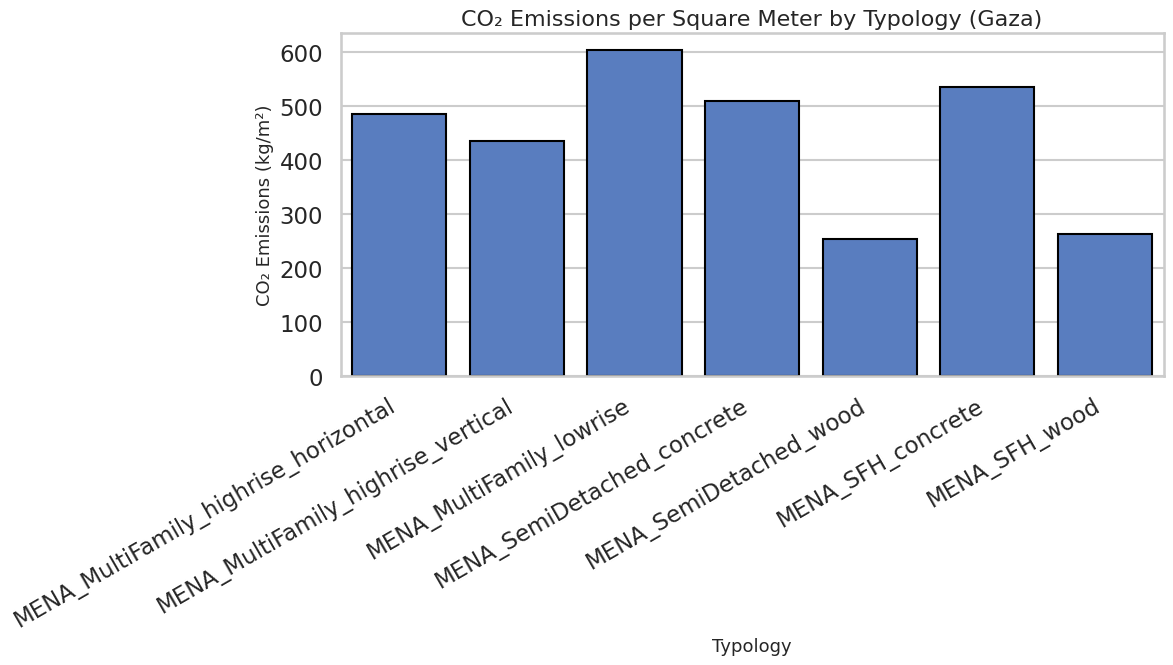

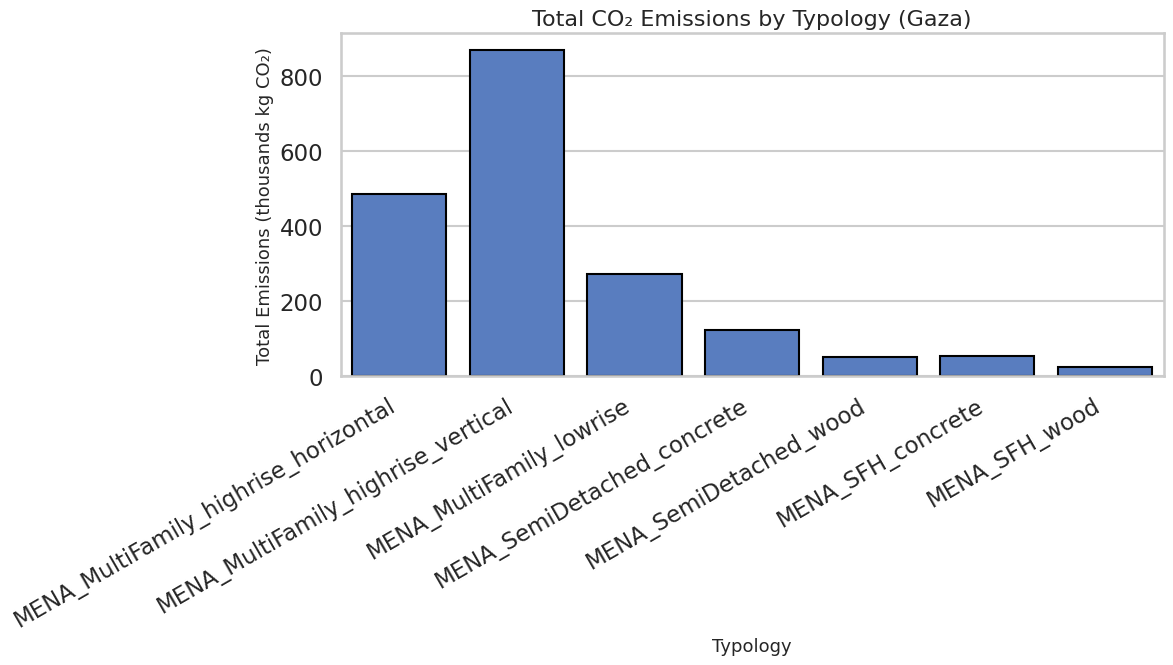

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Academic plotting style
sns.set(style="whitegrid", context="talk", palette="muted")
plt.rcParams["figure.figsize"] = (12, 7)

# Optional: Scale units (thousands of USD or kg)
final_dataset["cost_per_m2_k"] = final_dataset["cost_per_m2"] / 1000
final_dataset["total_cost_k"] = final_dataset["total_cost_usd"] / 1000
final_dataset["total_emissions_k"] = final_dataset["total_emissions_kg"] / 1000

# -----------------------------------
# 1. Cost per m² by Typology
# -----------------------------------
plt.figure()
sns.barplot(x="mena_typology", y="cost_per_m2_k", data=final_dataset, edgecolor="black")
plt.title("Material Cost per Square Meter by Typology (Gaza)", fontsize=16)
plt.ylabel("Cost per m² (thousands USD)", fontsize=13)
plt.xlabel("Typology", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------------
# 2. Total Construction Cost by Typology
# -----------------------------------
plt.figure()
sns.barplot(x="mena_typology", y="total_cost_k", data=final_dataset, edgecolor="black")
plt.title("Total Material Cost by Typology (Gaza)", fontsize=16)
plt.ylabel("Total Cost (thousands USD)", fontsize=13)
plt.xlabel("Typology", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------------
# 3. CO₂ Emissions per m² by Typology
# -----------------------------------
plt.figure()
sns.barplot(x="mena_typology", y="co2_per_m2", data=final_dataset, edgecolor="black")
plt.title("CO₂ Emissions per Square Meter by Typology (Gaza)", fontsize=16)
plt.ylabel("CO₂ Emissions (kg/m²)", fontsize=13)
plt.xlabel("Typology", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------------
# 4. Total CO₂ Emissions by Typology
# -----------------------------------
plt.figure()
sns.barplot(x="mena_typology", y="total_emissions_k", data=final_dataset, edgecolor="black")
plt.title("Total CO₂ Emissions by Typology (Gaza)", fontsize=16)
plt.ylabel("Total Emissions (thousands kg CO₂)", fontsize=13)
plt.xlabel("Typology", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
